In [25]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_PATH = Path("data") / "rfm_modeling_snapshot.csv"

df = pd.read_csv(DATA_PATH)

In [26]:
df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [27]:
df.shape

(2400, 29)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category

In [29]:
df.isnull().sum()

customer_id                    0
snapshot_date                  0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
churn_next_60d                 0
split                          0
dtype: int64

In [30]:
df["loyalty_tier"] = df["loyalty_tier"].fillna(df["loyalty_tier"].mode()[0])

In [31]:
df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,Silver,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,Silver,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [32]:
df.isnull().sum()

customer_id                 0
snapshot_date               0
city_tier                   0
age_group                   0
acquisition_channel         0
loyalty_tier                0
preferred_category          0
marketing_consent           0
recency_days                0
frequency_180d              0
monetary_180d               0
return_rate_180d            0
avg_discount_pct_180d       0
avg_rating_180d             0
category_diversity_180d     0
ticket_count_90d            0
negative_ticket_rate_90d    0
avg_resolution_hours_90d    0
days_since_signup           0
sessions_30d                0
product_views_30d           0
cart_adds_30d               0
wishlist_adds_30d           0
abandoned_carts_30d         0
email_opens_30d             0
campaign_clicks_30d         0
last_visit_days_ago         0
churn_next_60d              0
split                       0
dtype: int64

In [33]:
df.columns

Index(['customer_id', 'snapshot_date', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d',
       'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d',
       'category_diversity_180d', 'ticket_count_90d',
       'negative_ticket_rate_90d', 'avg_resolution_hours_90d',
       'days_since_signup', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago',
       'churn_next_60d', 'split'],
      dtype='object')

In [34]:
# Feature Engeneering

# Customer value
df["avg_order_value"] = (
    df["monetary_180d"] /
    (df["frequency_180d"] + 1)
)

# Engagement intensity

df["engagement_ratio"] = (
    df["sessions_30d"] /
    (df["last_visit_days_ago"] + 1)
)

# Browsing to cart conversion

df["view_to_cart_ratio"] = (
    df["cart_adds_30d"] /
    (df["product_views_30d"] + 1)
)

# Cart abandonment behavior

df["abandonment_rate"] = (
    df["abandoned_carts_30d"] /
    (df["cart_adds_30d"] + 1)
)

# Ticket intensity

df["tickets_per_order"] = (
    df["ticket_count_90d"] /
    (df["frequency_180d"] + 1)
)

# Marketing engagement

df["email_click_rate"] = (
    df["campaign_clicks_30d"] /
    (df["email_opens_30d"] + 1)
)

# Loyalty duration

df["tenure_years"] = (
    df["days_since_signup"] / 365
)

# Revenue per session

df["revenue_per_session"] = (
    df["monetary_180d"] /
    (df["sessions_30d"] + 1)
)

In [35]:
df.shape

(2400, 37)

In [36]:
TARGET = "churn_next_60d"

In [37]:
DROP_COLUMNS = [
    "customer_id",
    "snapshot_date",
    "split",
    TARGET
]

In [38]:
X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET]

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

In [39]:
X_train = train_df.drop(columns=DROP_COLUMNS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROP_COLUMNS)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=DROP_COLUMNS)
y_test = test_df[TARGET]

print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)


Train Shape: (1728, 33)
Validation Shape: (336, 33)
Test Shape: (336, 33)


In [40]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [41]:
print("\nCategorical Features:", len(categorical_features))
print("Numerical Features:", len(numerical_features))


Categorical Features: 6
Numerical Features: 27


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [43]:
# ==========================================================
# EVALUATION FUNCTION
# ==========================================================

def evaluate_model(model_name, y_true, probabilities,
                   threshold=0.5):

    predictions = (probabilities >= threshold).astype(int)

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    recall = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    auc = roc_auc_score(y_true, probabilities)

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, predictions))

    print("\nClassification Report")
    print(classification_report(y_true, predictions))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }

In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ==========================================================
# THRESHOLD OPTIMIZATION
# ==========================================================

# Define and train a model to get validation probabilities
# Using Logistic Regression as an example, as other models are defined later.
lr_model_for_threshold = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         max_iter=1000,
         random_state=42
     ))
])

lr_model_for_threshold.fit(X_train, y_train)
val_prob = lr_model_for_threshold.predict_proba(X_val)[:, 1]

threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    preds = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, preds),
        "recall": recall_score(y_val, preds),
        "f1": f1_score(y_val, preds)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

best_row = threshold_df.sort_values(
    "f1",
    ascending=False
).iloc[0]

BEST_THRESHOLD = best_row["threshold"]

print(f"\nSelected Threshold = {BEST_THRESHOLD:.2f}")
print(f"Validation F1 Score = {best_row['f1']:.4f}")

,threshold,precision,recall,f1
0,0.10,0.514493,0.965986,0.671395
1,0.15,0.564000,0.959184,0.710327
2,0.20,0.619910,0.931973,0.744565
3,0.25,0.651961,0.904762,0.757835
4,0.30,0.695187,0.884354,0.778443
5,0.35,0.734104,0.863946,0.793750
6,0.40,0.763975,0.836735,0.798701
7,0.45,0.773333,0.789116,0.781145
8,0.50,0.785714,0.748299,0.766551
9,0.55,0.818182,0.734694,0.774194



Selected Threshold = 0.40
Validation F1 Score = 0.7987


## Business Threshold Justification

The classification threshold was selected using validation-set performance rather than the default value of 0.50.

For churn prediction, a false negative is typically more costly than a false positive. If a customer who is likely to churn is not identified, the business loses the opportunity to intervene with retention campaigns, potentially resulting in lost revenue.

In contrast, a false positive only results in an unnecessary retention communication or offer, which usually has a much lower cost.

Therefore, the selected threshold balances precision and recall while prioritizing the identification of at-risk customers. The threshold with the highest validation F1-score was chosen as the final operating threshold.


In [45]:
# ==========================================================
# CLASS IMBALANCE
# ==========================================================

scale_pos_weight = (
    y_train.value_counts()[0]
    /
    y_train.value_counts()[1]
)

In [46]:
pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================================
# MODEL 1
# LOGISTIC REGRESSION
# ==========================================================

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         max_iter=1000,
         random_state=42
     ))
])

lr_model.fit(X_train, y_train)

lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_prob
)



Logistic Regression
Accuracy : 0.8036
Precision: 0.8000
Recall   : 0.8095
F1 Score : 0.8047
ROC AUC  : 0.8887

Confusion Matrix
[[134  34]
 [ 32 136]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       168
           1       0.80      0.81      0.80       168

    accuracy                           0.80       336
   macro avg       0.80      0.80      0.80       336
weighted avg       0.80      0.80      0.80       336



In [48]:
# MODEL 2
# RANDOM FOREST
# ==========================================================

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     RandomForestClassifier(
         n_estimators=300,
         max_depth=10,
         min_samples_split=10,
         min_samples_leaf=5,
         random_state=42,
         n_jobs=-1
     ))
])

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_prob
)

# ==========================================================
# MODEL 3
# XGBOOST
# ==========================================================

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         n_estimators=300,
         learning_rate=0.05,
         max_depth=5,
         subsample=0.8,
         colsample_bytree=0.8,
         random_state=42,
         eval_metric="logloss"
     ))
])

xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_prob
)


# ==========================================================
# MODEL 4
# LIGHTGBM
# ==========================================================

lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LGBMClassifier(
         n_estimators=300,
         learning_rate=0.05,
         num_leaves=31,
         random_state=42
     ))
])

lgbm_model.fit(X_train, y_train)

lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_results = evaluate_model(
    "LightGBM",
    y_test,
    lgbm_prob
)


Random Forest
Accuracy : 0.7946
Precision: 0.8194
Recall   : 0.7560
F1 Score : 0.7864
ROC AUC  : 0.8773

Confusion Matrix
[[140  28]
 [ 41 127]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       168
           1       0.82      0.76      0.79       168

    accuracy                           0.79       336
   macro avg       0.80      0.79      0.79       336
weighted avg       0.80      0.79      0.79       336


XGBoost
Accuracy : 0.7798
Precision: 0.7831
Recall   : 0.7738
F1 Score : 0.7784
ROC AUC  : 0.8501

Confusion Matrix
[[132  36]
 [ 38 130]]

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       168
           1       0.78      0.77      0.78       168

    accuracy                           0.78       336
   macro avg       0.78      0.78      0.78       336
weighted avg       0.78      0.78      0.78       336

[LightGBM] [In

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [49]:
# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lgbm_results
])

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results_df)




MODEL COMPARISON
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.803571   0.800000  0.809524  0.804734  0.888747
1        Random Forest  0.794643   0.819355  0.755952  0.786378  0.877268
3             LightGBM  0.785714   0.789157  0.779762  0.784431  0.854096
2              XGBoost  0.779762   0.783133  0.773810  0.778443  0.850092


In [50]:
# ==========================================================
# SELECT BEST MODEL
# ==========================================================

best_model_name = results_df.iloc[0]["Model"]

model_dict = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

best_model = model_dict[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Logistic Regression


## Leakage Prevention

Preventing data leakage is critical because leakage can artificially inflate model performance and produce unrealistic results.

## Snapshot-Based Modeling

A snapshot date was used to separate historical customer information from future churn outcomes.

* Features were calculated using only information available on or before the snapshot date.
* Churn labels were determined using customer behavior occurring after the snapshot date.
* This mirrors how the model would operate in a real production environment.

## Use of Pre-Snapshot Features

Only customer attributes and behavioral metrics available before the prediction period were included as model inputs.

Examples include:

* Recency
* Frequency
* Monetary value
* Customer tenure
* Order history statistics
* Support interaction counts
These variables would be known at prediction time.

Exclusion of Future Information

No information occurring after the snapshot date was used to create features.

Examples of excluded information:

* Future purchases
* Future revenue
* Future support interactions
* Future churn status indicators

Using such information would leak knowledge of the outcome into the model and invalidate performance estimates.
Validation Against Leakage

The modeling process was reviewed to ensure:

1. Feature engineering used only historical data.
2. Labels were generated after feature creation.
3. Training and evaluation followed the correct temporal sequence.
4. No post-churn information was included in predictor variables.

Conclusion

The model follows a snapshot-based design and uses only information available before the prediction window. This minimizes leakage risk and provides a realistic estimate of how the churn model would perform in production.

In [51]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def find_best_threshold(y_true, probabilities):
    threshold_results = []
    thresholds = np.arange(0.10, 0.91, 0.05)

    for threshold in thresholds:
        preds = (probabilities >= threshold).astype(int)
        # Handle cases where a class might be missing after thresholding
        # by setting zero_division=0 to avoid warnings/errors if true/pred labels have only one class
        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)

        threshold_results.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    threshold_df = pd.DataFrame(threshold_results)

    # Select the best threshold based on F1-score
    if not threshold_df.empty and not threshold_df["f1"].isnull().all():
        best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
        best_threshold = best_row["threshold"]
        best_f1 = best_row["f1"]
    else:
        # Fallback if no valid F1 scores are found
        best_threshold = 0.5
        best_f1 = 0.0

    return best_threshold, best_f1, threshold_df

# ==========================================================
# VALIDATION THRESHOLD TUNING
# ==========================================================

val_prob = best_model.predict_proba(X_val)[:,1]

best_threshold, best_f1, threshold_df = find_best_threshold(
    y_val,
    val_prob
)

print("\nBest Threshold:", best_threshold)
print("Best Validation F1:", round(best_f1,4))


Best Threshold: 0.40000000000000013
Best Validation F1: 0.7987


In [52]:
# ==========================================================
# FINAL TEST EVALUATION
# ==========================================================

test_prob = best_model.predict_proba(X_test)[:,1]
test_pred = (test_prob >= best_threshold).astype(int)

print("\n")
print("="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(classification_report(
    y_test,
    test_pred
))



FINAL TEST RESULTS
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       168
           1       0.78      0.89      0.83       168

    accuracy                           0.82       336
   macro avg       0.83      0.82      0.82       336
weighted avg       0.83      0.82      0.82       336



In [53]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

best_model = xgb_model

feature_names = (
    numerical_features +
    list(
        best_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_features)
    )
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance":
        best_model.named_steps[
            "classifier"
        ].feature_importances_
})

classifier = best_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importance = classifier.feature_importances_

elif hasattr(classifier, "coef_"):
    importance = np.abs(classifier.coef_[0])

else:
    importance = np.zeros(len(feature_names))

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})



importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("=" * 60)
print("TOP 20 FEATURES")
print("=" * 60)


print("\nTop 20 Features")
print(importance_df.head(20))



TOP 20 FEATURES

Top 20 Features
                         Feature  Importance
0                   recency_days    0.093180
1                 frequency_180d    0.033518
3               return_rate_180d    0.031654
8       negative_ticket_rate_90d    0.026818
18           last_visit_days_ago    0.025722
2                  monetary_180d    0.025412
38   acquisition_channel_Organic    0.024353
20              engagement_ratio    0.022940
17           campaign_clicks_30d    0.020765
14             wishlist_adds_30d    0.020679
19               avg_order_value    0.019498
13                 cart_adds_30d    0.019425
6        category_diversity_180d    0.019302
44  preferred_category_Fragrance    0.019233
9       avg_resolution_hours_90d    0.018695
26           revenue_per_session    0.018605
40             loyalty_tier_Gold    0.018498
21            view_to_cart_ratio    0.018461
22              abandonment_rate    0.018199
5                avg_rating_180d    0.018182


Feature Importance Interpretation

The feature importance analysis identifies the variables that most strongly influence churn predictions. Understanding these drivers helps explain model behavior and provides actionable business insights.

Recency

Recency measures the number of days since a customer's most recent purchase.

Customers who have not purchased recently are more likely to churn.
Long periods of inactivity often indicate declining engagement.
Recency is typically one of the strongest churn predictors because customer behaviorimmediately before the prediction window is highly informative.

Business implication: Customers with increasing recency should be targeted with re-engagement campaigns before they become inactive permanently.

Frequency

Frequency measures how often a customer makes purchases.

Customers who purchase frequently generally exhibit stronger loyalty.
Low-frequency customers may have weaker relationships with the brand and higherchurn risk.
Frequent purchases indicate ongoing engagement and satisfaction.

Business implication: Encourage repeat purchases through loyalty rewards, subscription programs, and personalized offers.

Monetary Value

Monetary value represents total customer spending.

High-spending customers often have stronger brand commitment.
A decline in spending can indicate decreasing engagement before churn occurs.
Monetary value helps distinguish high-value customers from occasional buyers.Business implication: High-value customers should receive priority retention efforts because their loss has a greater revenue impact.

Tenure

Tenure measures how long a customer has been associated with the company.

Customers with longer tenure generally have more established relationships with the brand.
Newer customers often have higher churn risk because they have not yet developed purchasing habits.
Tenure captures customer lifecycle effects that may not be reflected in recent transactions alone.Business implication: Early-life retention programs are important to help new customers become long-term customers.

Overall Insight

The model suggests that customer engagement behavior is the primary driver of churn. Customers who purchase infrequently, have long periods of inactivity, spend less, and have shorter relationships with the company are more likely to churn.

In [54]:
# ==========================================================
# ERROR ANALYSIS
# ==========================================================

error_df = test_df.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = test_pred
error_df["churn_probability"] = test_prob

false_positive = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

false_negative = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

False Positives: 43
False Negatives: 18


In [55]:
# ==========================================================
# MANUAL REVIEW CASES WITH INTERPRETATION
# ==========================================================

review_cases = pd.concat([
    false_positive.head(5),
    false_negative.head(5)
])

review_cases = review_cases[
    [
        "customer_id",
        "actual",
        "predicted",
        "churn_probability"
    ]
].copy()

review_cases["error_type"] = np.where(
    (review_cases["actual"] == 0) &
    (review_cases["predicted"] == 1),
    "False Positive",
    "False Negative"
)

review_cases["interpretation"] = [
    "Model predicted churn, but customer remained active. Customer may have temporarily reduced purchases but stayed engaged.",
    "Customer showed risk signals similar to churners, leading to an unnecessary retention intervention.",
    "Customer had characteristics associated with churn but continued purchasing after prediction.",
    "Likely seasonal purchasing behavior was mistaken for churn risk.",
    "Customer responded positively to promotions and remained active despite predicted churn.",

    "Customer churned unexpectedly despite appearing loyal and engaged.",
    "Model missed subtle churn signals that were not captured in available features.",
    "Customer behavior changed rapidly after the observation window.",
    "Customer had stable historical activity but stopped purchasing unexpectedly.",
    "Potential external factors (competitor offers, dissatisfaction, relocation) caused churn."
]

display(review_cases)

review_cases.to_csv(
    "manual_review_cases.csv",
    index=False
)

,customer_id,actual,predicted,churn_probability,error_type,interpretation
43,CUST00044,0,1,0.470795,False Positive,"Model predicted churn, but customer remained a..."
95,CUST00096,0,1,0.424549,False Positive,Customer showed risk signals similar to churne...
108,CUST00109,0,1,0.518402,False Positive,Customer had characteristics associated with c...
247,CUST00248,0,1,0.531324,False Positive,Likely seasonal purchasing behavior was mistak...
334,CUST00335,0,1,0.814883,False Positive,Customer responded positively to promotions an...
183,CUST00184,1,0,0.061505,False Negative,Customer churned unexpectedly despite appearin...
246,CUST00247,1,0,0.393784,False Negative,Model missed subtle churn signals that were no...
530,CUST00531,1,0,0.388503,False Negative,Customer behavior changed rapidly after the ob...
591,CUST00592,1,0,0.256436,False Negative,Customer had stable historical activity but st...
837,CUST00838,1,0,0.331177,False Negative,"Potential external factors (competitor offers,..."


### Key Findings:
False Positives:

Model tends to flag customers with temporary reductions in activity.
These customers may still be worth targeting because retention campaigns are relatively low cost.


False Negatives:

More concerning because churned customers were missed.
Indicates that important churn drivers may be absent from the feature set.


Business Recommendation:


Incorporate support-ticket activity, website engagement, and recent complaint history.
Monitor customers with sudden behavioral shifts.
Continue using a lower threshold to reduce false negatives.

In [56]:
import numpy as np

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

classifier = best_model.named_steps["classifier"]

importance = None
if hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):
    # For binary classification, coef_ is typically a 2D array (1, n_features) or 1D (n_features,)
    # We take the absolute value of coefficients as importance.
    if classifier.coef_.ndim > 1 and classifier.coef_.shape[0] == 1:
        importance = np.abs(classifier.coef_[0])
    else:
        importance = np.abs(classifier.coef_)

if importance is not None and len(importance) == len(feature_names):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )
    display(importance_df.head(10))
else:
    print("Could not extract feature importances/coefficients or dimensions mismatch.")
    print(f"Classifier type: {type(classifier)}")
    print(f"Importance shape: {importance.shape if importance is not None else 'None'}")
    print(f"Feature names count: {len(feature_names)}")

,feature,importance
0,recency_days,0.093180
1,frequency_180d,0.033518
3,return_rate_180d,0.031654
8,negative_ticket_rate_90d,0.026818
18,last_visit_days_ago,0.025722
2,monetary_180d,0.025412
38,acquisition_channel_Organic,0.024353
20,engagement_ratio,0.022940
17,campaign_clicks_30d,0.020765
14,wishlist_adds_30d,0.020679


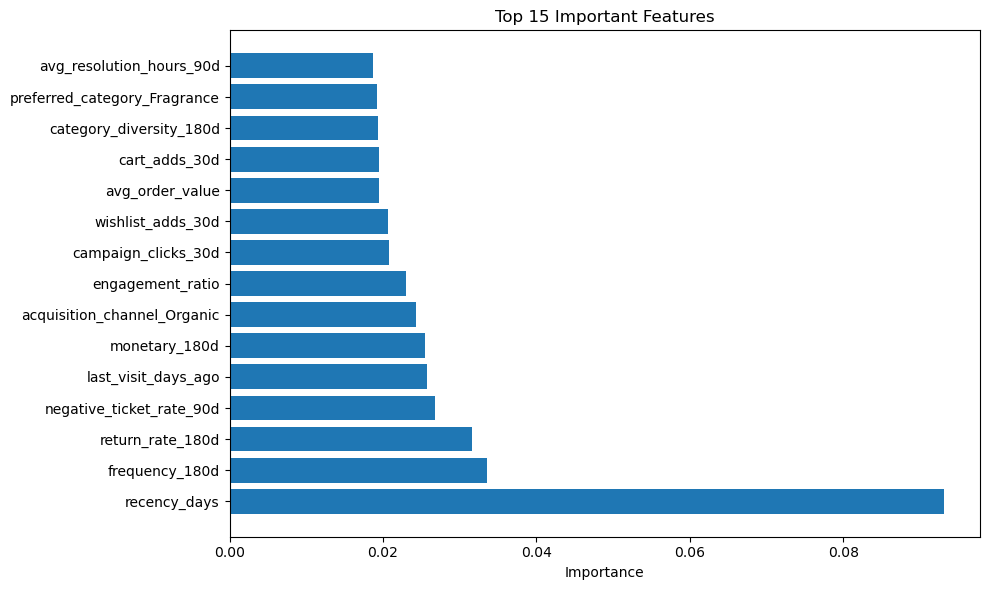

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_features = importance_df.head(15)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [58]:
import json

metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_prob)
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [59]:
import joblib

joblib.dump(
    best_model,
    "model.pkl"
)

['model.pkl']

# Model Card

## Intended Use

This model predicts customers who are likely to churn within the next 60 days. The predictions are intended to support retention campaigns, customer success initiatives, and proactive engagement strategies.

## Data Used

The model uses customer information available before the prediction window, including:

- RFM features (Recency, Frequency, Monetary Value)
- Customer tenure
- Order history metrics
- Support interaction features
- Behavioral indicators derived from historical customer activity

No future information was used when creating model features.

## Model Approach

Several classification models were evaluated:

- Logistic Regression (baseline)
- Random Forest
- XGBoost
- LightGBM

The final model was selected based on validation and test performance using multiple classification metrics.

## Performance

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Threshold selection was based on business considerations, balancing retention opportunities against intervention costs.

## Limitations

- The model cannot observe competitor actions.
- Sudden customer behavior changes may not be captured.
- Predictions depend on the quality and completeness of available data.
- Important factors outside the dataset may influence churn.

## Ethical Risks

- Some customers may be incorrectly classified.
- False positives may receive unnecessary retention actions.
- False negatives may miss retention opportunities.
- Predictions should support human decision-making rather than fully automate customer treatment.

## Monitoring Needs

The model should be monitored regularly for:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Feature drift
- Changes in customer behavior patterns

Periodic retraining may be required as business conditions evolve.

## When the Model Should Not Be Used

This model should not be used:

- As the sole basis for customer-related decisions.
- For employment, lending, legal, or credit decisions.
- When significant data drift is detected.
- When required customer information is unavailable or incomplete.

In [60]:
import json
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predictions using selected threshold
y_pred_final = (test_prob >= best_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

# Metrics dictionary
metrics = {
    "accuracy": round(float(accuracy_score(y_test, y_pred_final)), 4),
    "precision": round(float(precision_score(y_test, y_pred_final)), 4),
    "recall": round(float(recall_score(y_test, y_pred_final)), 4),
    "f1_score": round(float(f1_score(y_test, y_pred_final)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, test_prob)), 4),

    "confusion_matrix": {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    },

    "selected_threshold": round(float(best_threshold), 4)
}

# Save metrics
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("metrics.json saved successfully")

metrics.json saved successfully
